In [20]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'left')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['target_column', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['target_column', 'target_instances', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_30620\4276283625.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_30620\4276283625.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_30620\4276283625.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

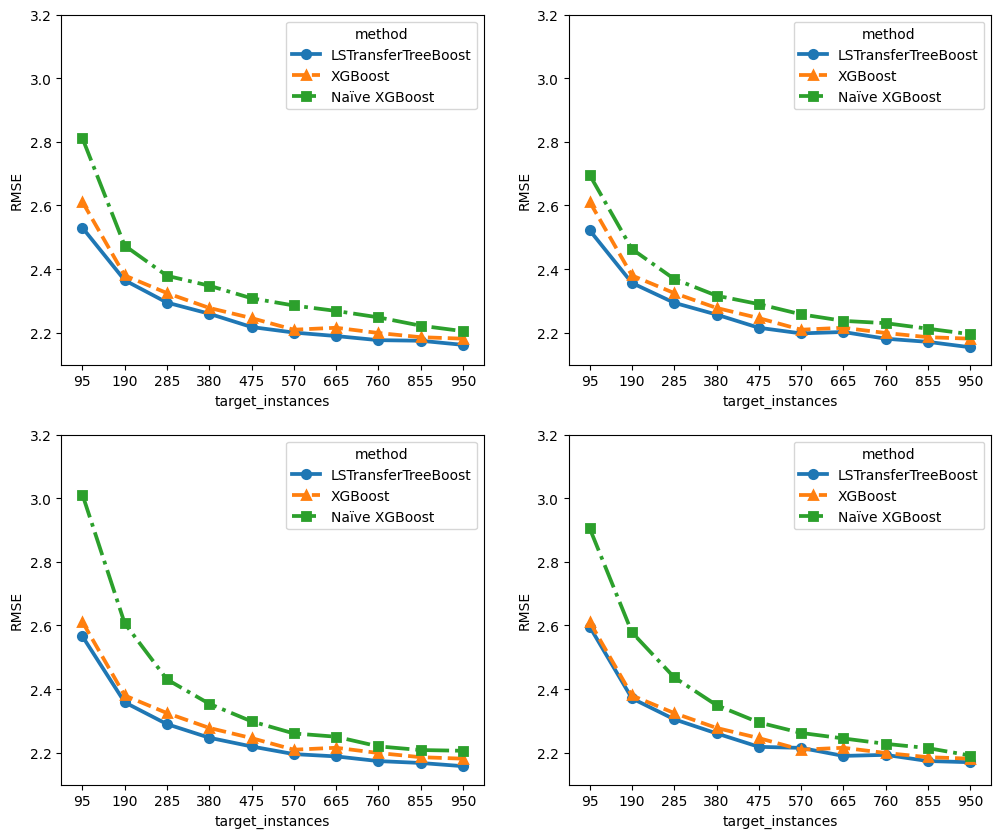

In [22]:
from matplotlib.lines import Line2D
plt.figure(figsize = (12,10))
for d in [1,2,3,4]:

    target_column  = 'Hgv'
   
    dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_DGV_rs_{d}_250926.csv', index_col = [0])
    dat = dat.reset_index(drop=True) 
    dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])
  
    best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
        dat,
    ['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
    )
    



    data = pd.read_csv(f'results/xgboost_ablation_DGV_rs_{d}_250926.csv')
    xgboost_data = data[data['method'] == 'xgboost']
    naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
    naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
    naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
    xgboost_data['method'] = 'XGBoost'

    best_XGBoost, _ = topk_per_d_per_method(
        xgboost_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )

    """
    best_naive_transfer, _ = topk_per_d_per_method(
        naive_transfer_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
    )

    """
    best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
        naive_transfer_data_with_dummy,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )
    



    best_mlp, _ = topk_per_d_per_method(
        f'../results/MLP_ablation_rs.csv',
    ['target_column', 'target_instances', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
    )



    trada = pd.read_csv(f'../results/tradaboost_ablation_rs.csv')
    trada = trada.rename(columns = {'train_size_': 'target_instances'})
    best_tradaboost, kk = topk_per_d_per_method(
        trada,
    ['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=5
    )


    #df = best_XGBoost
    df = best_LSTransferTreeBoost
    df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
    #df = pd.concat([df, best_naive_transfer])
    df = pd.concat([df, best_naive_transfer_with_dummy])
    #df = pd.concat([df, best_mlp])
    #df = pd.concat([df, best_tradaboost])
    plt.subplot(2,2,d)
    sns.pointplot(data = df[df['target_column'] == target_column], x = 'target_instances', y = 'rmse', hue = 'method',  errorbar=None, 
                    markers=['o', '^', 's'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])
    plt.ylabel('RMSE')
    plt.ylim([2.1, 3.2])  
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)

plt.savefig('vizes/HGV_DGV.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 300)



C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_30620\2470411723.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_30620\2470411723.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_30620\2470411723.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

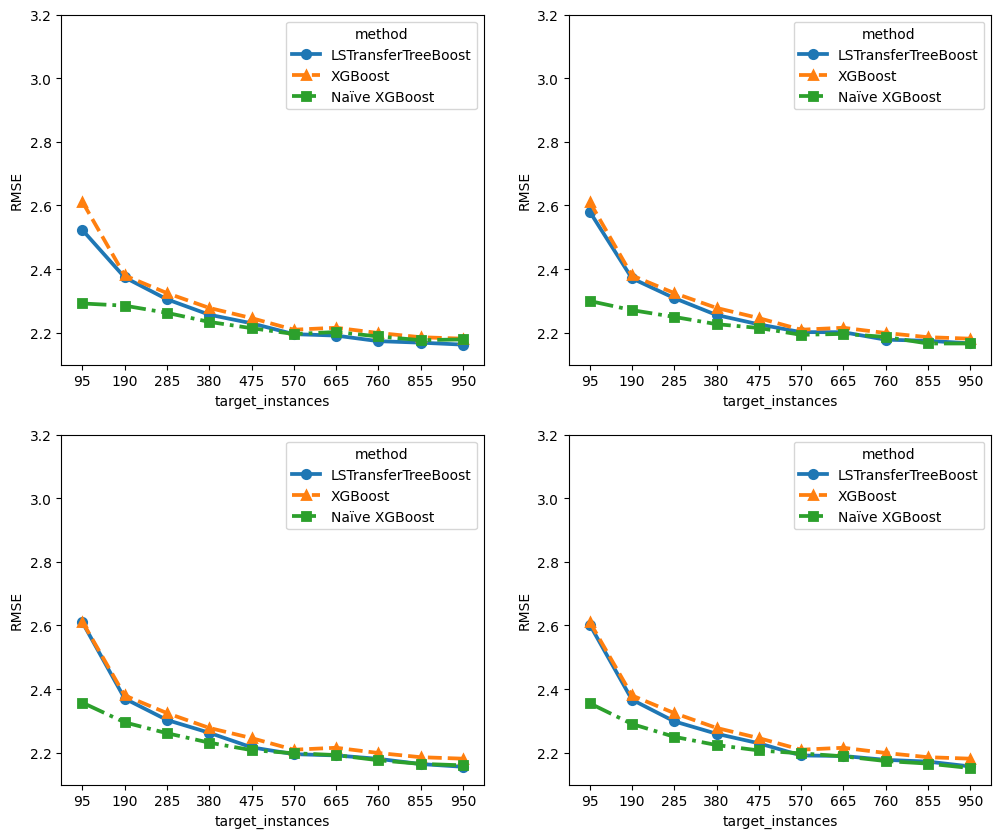

In [23]:
from matplotlib.lines import Line2D
plt.figure(figsize = (12,10))
for d in [1,2,3,4]:

    target_column  = 'Hgv'
   
    dat = pd.read_csv(f'../results/LSTransferTreeBoost_ablation_rs_{d}_250927.csv', index_col = [0])
    dat = dat.reset_index(drop=True) 
    dat = dat.sort_values(by = ['seed', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])
  
    best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
        dat,
    ['target_column', 'target_instances', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=10
    )
    



    data = pd.read_csv(f'results/xgboost_ablation_HGV_rs_{d}_250926.csv')
    xgboost_data = data[data['method'] == 'xgboost']
    naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
    naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
    naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'
    xgboost_data['method'] = 'XGBoost'

    best_XGBoost, _ = topk_per_d_per_method(
        xgboost_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )

    """
    best_naive_transfer, _ = topk_per_d_per_method(
        naive_transfer_data,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=5
    )

    """
    best_naive_transfer_with_dummy, jk = topk_per_d_per_method(
        naive_transfer_data_with_dummy,
    ['target_column', 'target_instances', 'v', 'target_tree_size'], k=10
    )
    



    best_mlp, _ = topk_per_d_per_method(
        f'../results/MLP_ablation_rs.csv',
    ['target_column', 'target_instances', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
    )



    trada = pd.read_csv(f'../results/tradaboost_ablation_rs.csv')
    trada = trada.rename(columns = {'train_size_': 'target_instances'})
    best_tradaboost, kk = topk_per_d_per_method(
        trada,
    ['target_column', 'target_instances', 'n_estimators','lr','tree_size'], k=5
    )


    #df = best_XGBoost
    df = best_LSTransferTreeBoost
    df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
    #df = pd.concat([df, best_naive_transfer])
    df = pd.concat([df, best_naive_transfer_with_dummy])
    #df = pd.concat([df, best_mlp])
    #df = pd.concat([df, best_tradaboost])
    plt.subplot(2,2,d)
    sns.pointplot(data = df[df['target_column'] == target_column], x = 'target_instances', y = 'rmse', hue = 'method',  errorbar=None, 
                    markers=['o', '^', 's'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])
    plt.ylabel('RMSE')
    plt.ylim([2.1, 3.2])  
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)

plt.savefig('vizes/HGV_HGV.png', bbox_inches = 'tight', pad_inches = 0.1, dpi = 300)


